In [8]:
import numpy as np
import matplotlib.pyplot as plt
from joblib import Parallel, delayed
from pynamicalsys import DiscreteDynamicalSystem as dds

In [2]:
u = 0.5
ds = dds(model="logistic map")

In [3]:
%%time
u = 0.5
param_range = (2.4, 4, 500)
lypnv = np.zeros(param_range[2])
for i in range(param_range[2]):
    parameters = param_range[0] + i * (param_range[1] - param_range[0]) / (param_range[2] - 1)

    lypnv[i] = ds.lyapunov(u, 1000, parameters=parameters, transient_time=500)

CPU times: user 318 ms, sys: 10.9 ms, total: 329 ms
Wall time: 340 ms


In [4]:
%%time
transient_time = 10000
total_time = 1000 + transient_time
u = 0.5
param_range = (2.4, 4, 500)
rte = np.zeros(param_range[2])
for i in range(param_range[2]):
    parameters = param_range[0] + i * (param_range[1] - param_range[0]) / (param_range[2] - 1)
    ds.set_parameters(parameters)
    rte[i] = ds.recurrence_time_entropy(u, total_time, transient_time=transient_time, threshold_mode="rr")

CPU times: user 3.5 s, sys: 925 ms, total: 4.43 s
Wall time: 4.45 s


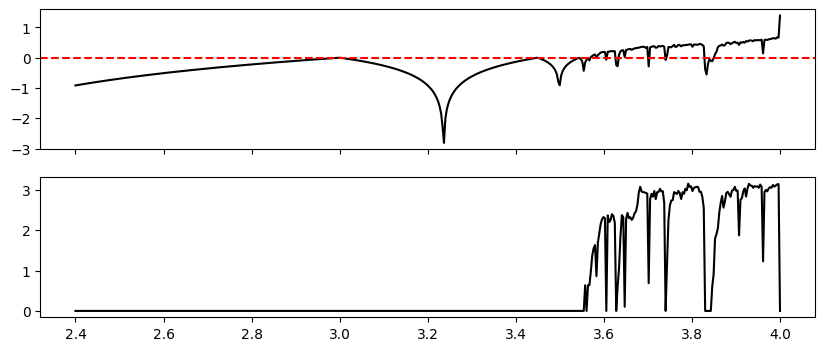

In [5]:
fig, ax = plt.subplots(2, 1, figsize=(10, 4), sharex=True)
ax[0].plot(np.linspace(param_range[0], param_range[1], param_range[2]), lypnv, "k")
# Plot line at y=0
ax[0].axhline(0, color="red", linestyle="--")

ax[1].plot(np.linspace(param_range[0], param_range[1], param_range[2]), rte, "k")

In [6]:
ds = dds(model="standard map")
ds.set_parameters(1.5)

In [28]:
grid_size = 300
total_time = 5000
x = np.linspace(0, 1, grid_size)
y = np.linspace(0, 1, grid_size)
x, y = np.meshgrid(x, y, indexing="ij")

In [29]:
rte = Parallel(n_jobs=-1)(delayed(ds.recurrence_time_entropy)([x[i, j], y[i, j]], total_time, threshold_mode="std") for i in range(grid_size) for j in range(grid_size))

In [30]:
rte = np.array(rte).reshape(grid_size, grid_size)

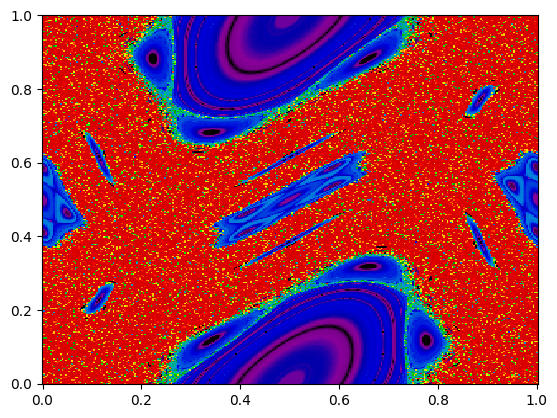

In [31]:
plt.pcolormesh(x, y, rte, cmap="nipy_spectral", vmin=0, vmax=6)